In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
df = pd.read_csv("../data/coffee_sales.csv")
df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2025,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2025,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2025,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   year              149116 non-null  int64  
 2   transaction_time  149116 non-null  object 
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  object 
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  object 
 9   product_type      149116 non-null  object 
 10  product_detail    149116 non-null  object 
dtypes: float64(1), int64(5), object(5)
memory usage: 12.5+ MB


In [8]:
df.describe()

,transaction_id,year,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116.0,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2025.0,1.438276,5.342063,47.918607,3.382219
std,43153.600016,0.0,0.542509,2.074241,17.930020,2.658723
min,1.000000,2025.0,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2025.0,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2025.0,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2025.0,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2025.0,8.000000,8.000000,87.000000,45.000000


In [10]:
df.columns

Index(['transaction_id', 'year', 'transaction_time', 'transaction_qty',
       'store_id', 'store_location', 'product_id', 'unit_price',
       'product_category', 'product_type', 'product_detail'],
      dtype='object')

In [11]:
df.isnull().sum()

transaction_id      0
year                0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df = df[(df['transaction_qty'] > 0) & (df['unit_price'] > 0)]

In [14]:
df['revenue'] = df['transaction_qty'] * df['unit_price']

In [17]:
df['transaction_time'] = pd.to_datetime(df['transaction_time'],format='%H:%M:%S')

In [18]:
df['hour'] = df['transaction_time'].dt.hour

In [19]:
df['day_of_week'] = df['transaction_time'].dt.day_name()

In [20]:
def time_bucket(hour):

    if 6 <= hour <= 11:
        return "Morning"

    elif 12 <= hour <= 16:
        return "Afternoon"

    elif 17 <= hour <= 21:
        return "Evening"

    else:
        return "Late Night"

df['time_bucket'] = df['hour'].apply(time_bucket)

In [21]:
df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,hour,day_of_week,time_bucket
0,1,2025,2026-03-09 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,7,Monday,Morning
1,2,2025,2026-03-09 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,7,Monday,Morning
2,3,2025,2026-03-09 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,7,Monday,Morning
3,4,2025,2026-03-09 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,7,Monday,Morning
4,5,2025,2026-03-09 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,7,Monday,Morning


In [22]:
daily_sales = df.groupby('day_of_week')['revenue'].sum().reset_index()
daily_sales

,day_of_week,revenue
0,Monday,698812.33


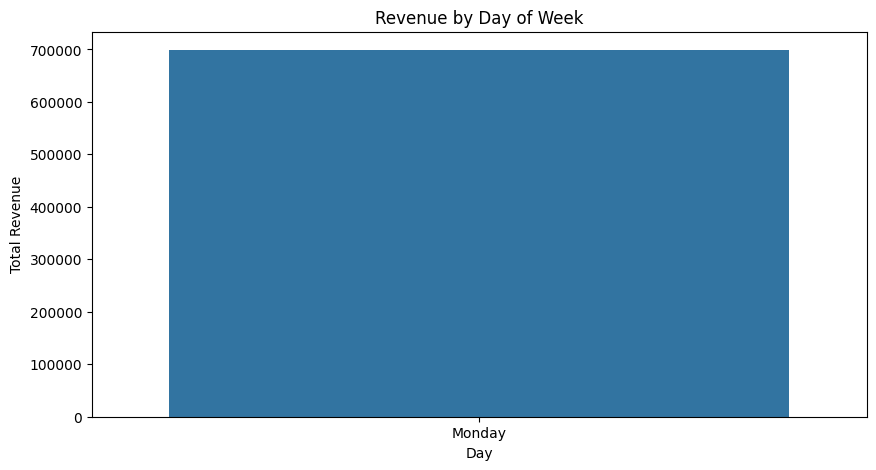

In [23]:
plt.figure(figsize=(10,5))

sns.barplot(x='day_of_week', y='revenue', data=daily_sales)

plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Revenue")

plt.show()

In [24]:
hourly_sales = df.groupby('hour')['revenue'].sum().reset_index()
hourly_sales

,hour,revenue
0,6,21900.27
1,7,63526.47
2,8,82699.87
3,9,85169.53
4,10,88673.39
5,11,46319.14
6,12,40192.79
7,13,40367.45
8,14,41304.74
9,15,41733.10


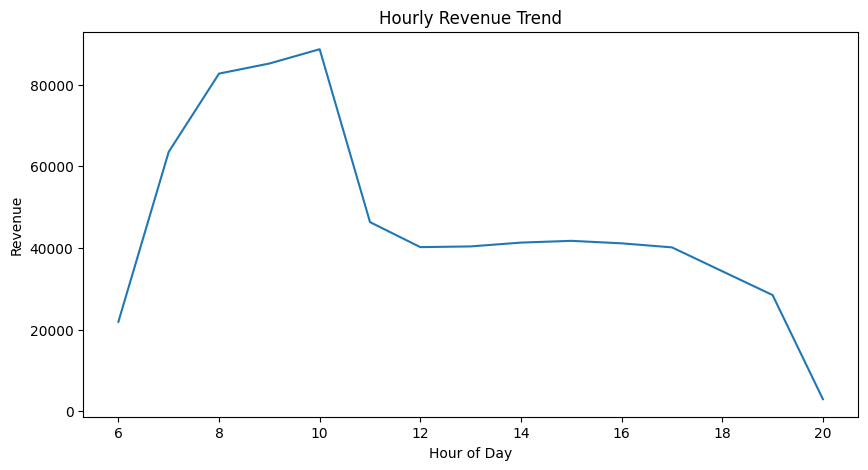

In [25]:
plt.figure(figsize=(10,5))

sns.lineplot(x='hour', y='revenue', data=hourly_sales)

plt.title("Hourly Revenue Trend")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue")

plt.show()

In [26]:
store_sales = df.groupby('store_location')['revenue'].sum().reset_index()
store_sales

,store_location,revenue
0,Astoria,232243.91
1,Hell's Kitchen,236511.17
2,Lower Manhattan,230057.25


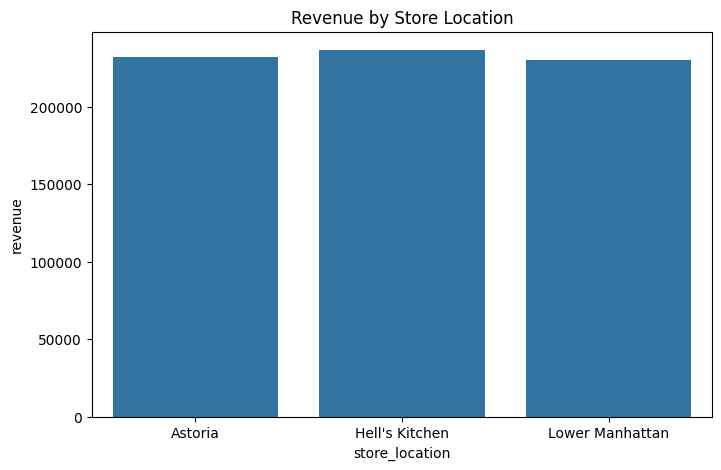

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(x='store_location', y='revenue', data=store_sales)

plt.title("Revenue by Store Location")

plt.show()

In [28]:
time_bucket_sales = df.groupby('time_bucket')['revenue'].sum().reset_index()
time_bucket_sales

,time_bucket,revenue
0,Afternoon,204720.83
1,Evening,105802.83
2,Morning,388288.67


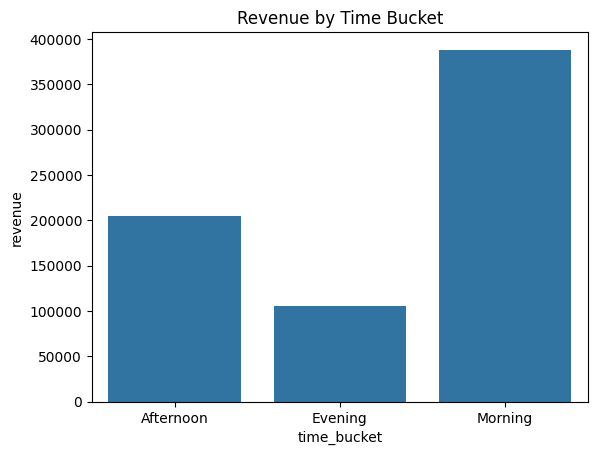

In [29]:
sns.barplot(x='time_bucket', y='revenue', data=time_bucket_sales)
plt.title("Revenue by Time Bucket")
plt.show()

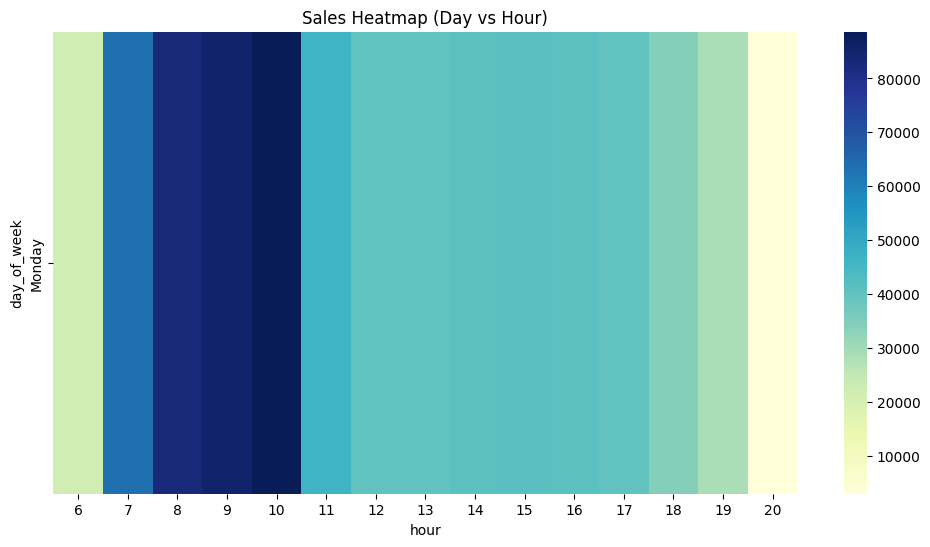

In [30]:
pivot_table = df.pivot_table(
    values='revenue',
    index='day_of_week',
    columns='hour',
    aggfunc='sum'
)

plt.figure(figsize=(12,6))

sns.heatmap(pivot_table, cmap="YlGnBu")

plt.title("Sales Heatmap (Day vs Hour)")

plt.show()

In [ ]:
Project Conclusion and Insights
The sales trend and time-based analysis of Afficionado Coffee Roasters provides useful insights into customer purchasing behavior across different time periods.
From the analysis, it was observed that most transactions occur during the morning hours, indicating that customers frequently purchase coffee before starting their daily activities. This pattern aligns with typical coffee consumption habits.
The hourly sales analysis shows that peak demand occurs during early morning hours, while sales gradually decline in the afternoon and evening periods. This information can help store managers allocate staff efficiently during busy hours and reduce operational costs during slower periods.
Although the dataset mainly contains transactions from Monday, the analysis still highlights clear time-based patterns that can guide operational planning.
Key Takeaways
Morning hours generate the highest sales.
Customer activity decreases during later hours of the day.
Time-based analysis helps optimize staffing and operational planning.
Data-driven insights can improve overall store performance.